In [44]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vishwasaditya/student-dataset/student-por.csv
/kaggle/input/datasets/vishwasaditya/student-performance-dataset/student-mat.csv


In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay,
    mean_absolute_error, r2_score, mean_squared_error
)
from xgboost import XGBClassifier, XGBRegressor
import shap
import joblib

path = '/kaggle/input/datasets/vishwasaditya/student-performance-dataset/student-mat.csv'
df = pd.read_csv(path, sep=';')

df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [46]:
df['G1'] = pd.to_numeric(df['G1'], errors='coerce').fillna(0).astype(int)
df['G2'] = pd.to_numeric(df['G2'], errors='coerce').fillna(0).astype(int)
df['G2']

0       6
1       5
2       8
3      14
4      10
       ..
390     9
391    16
392     8
393    12
394     9
Name: G2, Length: 395, dtype: int64

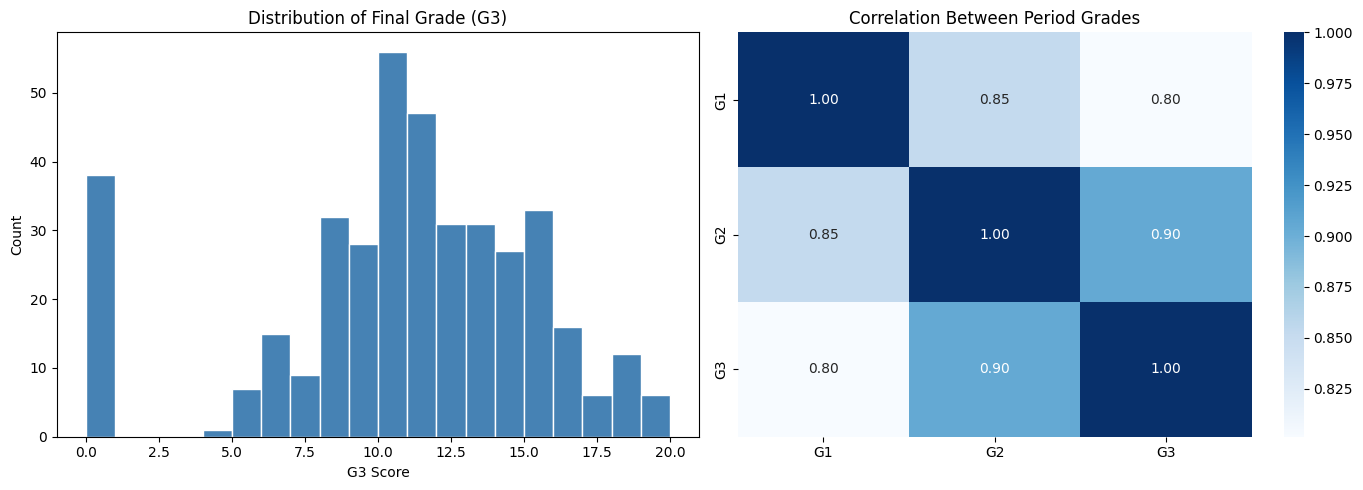

In [47]:
# Distribution of Final Grades (G3)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['G3'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Final Grade (G3)')
axes[0].set_xlabel('G3 Score')
axes[0].set_ylabel('Count')

# G1, G2, G3 correlation
grade_corr = df[['G1', 'G2', 'G3']].corr()
sns.heatmap(grade_corr, annot=True, cmap='Blues', ax=axes[1], fmt='.2f')
axes[1].set_title('Correlation Between Period Grades')

plt.tight_layout()
plt.show()

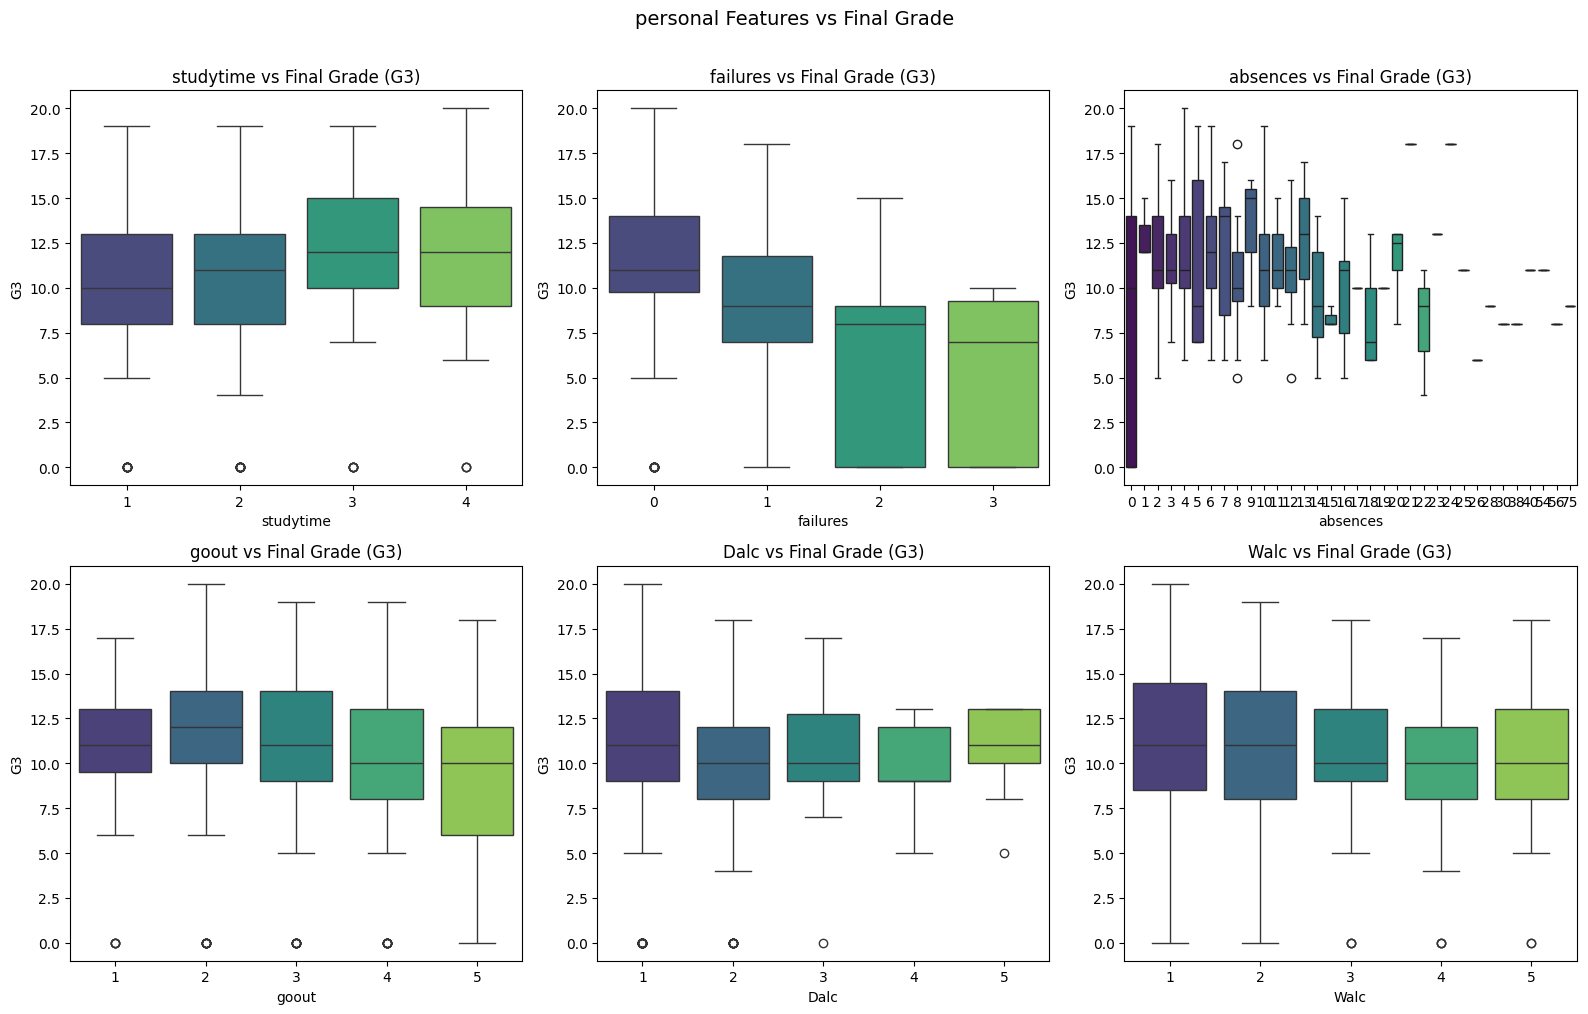

In [48]:
# Key behavioural features vs G3
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

features_to_plot = ['studytime', 'failures', 'absences', 'goout', 'Dalc', 'Walc']
for i, feat in enumerate(features_to_plot):
    sns.boxplot(x=df[feat], y=df['G3'], ax=axes[i], palette='viridis')
    axes[i].set_title(f'{feat} vs Final Grade (G3)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('G3')

plt.suptitle('personal Features vs Final Grade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

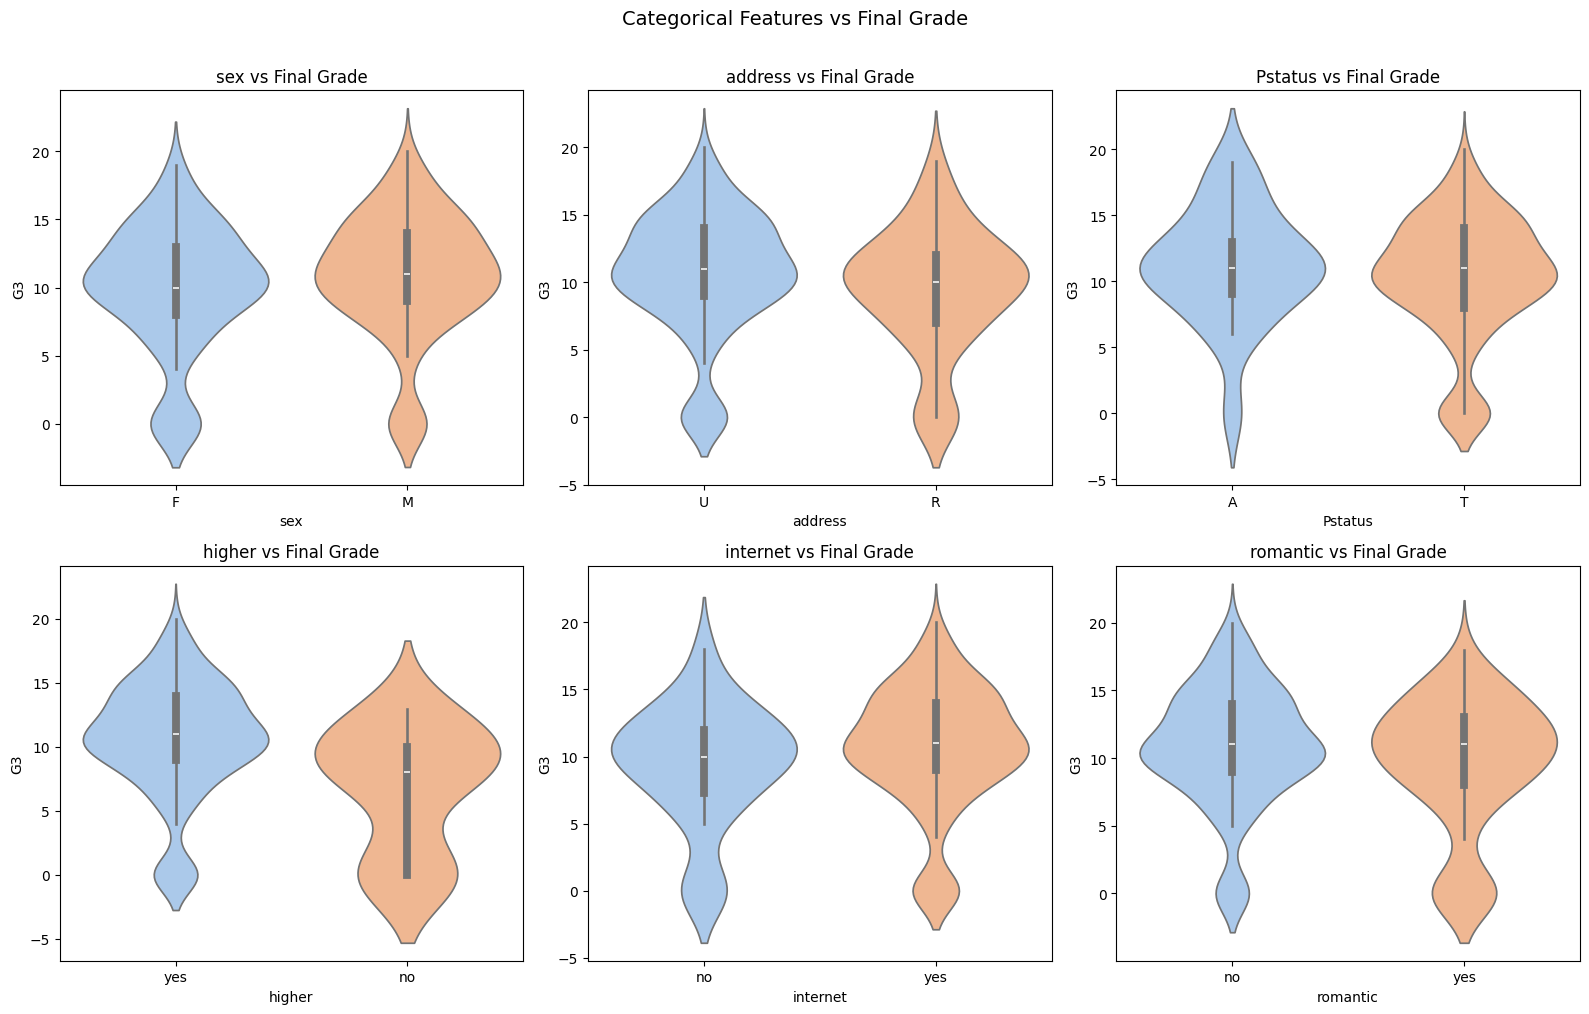

In [49]:
# Categorical features vs G3
cat_features = ['sex', 'address', 'Pstatus', 'higher', 'internet', 'romantic']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    sns.violinplot(x=df[feat], y=df['G3'], ax=axes[i], palette='pastel')
    axes[i].set_title(f'{feat} vs Final Grade')

plt.suptitle('Categorical Features vs Final Grade', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [50]:
df_model = df.copy()

# --- Encode binary yes/no ---
binary_cols = ['schoolsup','famsup','paid','activities','nursery','higher','internet','romantic']
for col in binary_cols:
    df_model[col] = df_model[col].map({'yes': 1, 'no': 0})

df_model['school']  = df_model['school'].map({'GP': 0, 'MS': 1})
df_model['sex']     = df_model['sex'].map({'F': 0, 'M': 1})
df_model['address'] = df_model['address'].map({'U': 0, 'R': 1})
df_model['famsize'] = df_model['famsize'].map({'LE3': 0, 'GT3': 1})
df_model['Pstatus'] = df_model['Pstatus'].map({'T': 0, 'A': 1})

le = LabelEncoder()
for col in ['Mjob', 'Fjob', 'reason', 'guardian']:
    df_model[col] = le.fit_transform(df_model[col])

# --- Feature Engineering (mid-semester safe only) ---
df_model['G1_deviation'] = df_model['G1'] - df_model['G1'].mean()
df_model['G1_below_pass'] = (df_model['G1'] < 10).astype(int)
df_model['alcohol_risk'] = df_model['Dalc'] + df_model['Walc']
df_model['social_risk'] = df_model['goout'] + df_model['romantic']
df_model['support_score'] = (df_model['schoolsup'] + df_model['famsup'] + 
                             df_model['internet'] + df_model['higher'])
df_model['parent_education'] = df_model['Medu'] + df_model['Fedu']
df_model['effective_time'] = df_model['studytime'] - df_model['traveltime']
df_model['parent_job_avg'] = (df_model['Mjob'] + df_model['Fjob']) / 2
df_model['focus_factor'] = df_model['studytime'] / (df_model['absences'] + 1)

cols_to_drop = [
    'Dalc', 'Walc', 'goout', 'schoolsup', 'famsup', 
    'internet', 'higher', 'Medu', 'Fedu',
    'studytime', 'traveltime','Mjob','Fjob'
]

df_model = df_model.drop(columns=cols_to_drop)

# --- Targets ---
df_model['at_risk'] = (df_model['G3'] < 10).astype(int)   # classifier target
# regressor target is G3 itself

# --- Features: exclude G2, G3, at_risk ---
EXCLUDE = ['G2', 'G3', 'at_risk']
feature_cols = [c for c in df_model.columns if c not in EXCLUDE]

X  = df_model[feature_cols]
y_clf = df_model['at_risk']      # classification target
y_reg = df_model['G3']           # regression target


print(f'\nAt-risk students : {y_clf.sum()} ({y_clf.mean()*100:.1f}%)')
print(f'G3 mean ± std    : {y_reg.mean():.2f} ± {y_reg.std():.2f}')



At-risk students : 130 (32.9%)
G3 mean ± std    : 10.42 ± 4.58


In [51]:
X_train, X_test, yclf_train, yclf_test, yreg_train, yreg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.2, random_state=42, stratify=y_clf
)

In [53]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

baseline_weight = (yclf_train==0).sum() / (yclf_train==1).sum()

param_grid_clf = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 400],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.8, 1.0],
    'scale_pos_weight': [baseline_weight, baseline_weight * 1.2] 
}

grid_search_clf = GridSearchCV(
    estimator=XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss'),
    param_grid=param_grid_clf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

print("Starting Classifier Grid Search... ")
grid_search_clf.fit(X_train, yclf_train)

print(f"\nBest Parameters: {grid_search_clf.best_params_}")
print(f"Best ROC-AUC Score from Grid Search: {grid_search_clf.best_score_:.4f}")

best_xgb_clf = grid_search_clf.best_estimator_

Starting Classifier Grid Search... 
Fitting 5 folds for each of 324 candidates, totalling 1620 fits

Best Parameters: {'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 400, 'scale_pos_weight': np.float64(2.446153846153846), 'subsample': 1.0}
Best ROC-AUC Score from Grid Search: 0.9283


In [54]:
# === Features & Target ===
# Exclude G3 and at_risk from features; keep G1, G2 as early-warning signals
EXCLUDE_COLS = ['G2','G3', 'at_risk']
feature_cols = [c for c in df_model.columns if c not in EXCLUDE_COLS]

X = df_model[feature_cols]
y = df_model['at_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Features used: {len(feature_cols)}")

Train size: 316 | Test size: 79
Features used: 27


In [55]:
from sklearn.model_selection import GridSearchCV

# 1. Define the parameter grid
# We stay near your current values but explore higher/lower complexity
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [200, 300, 500],
    'min_child_weight': [1, 3],
    'subsample': [0.9,1],
    'colsample_bytree': [0.8, 0.9]
}

# 2. Initialize the Grid Search
# Using R² as the scoring metric to match your previous evaluation
grid_search = GridSearchCV(
    estimator=XGBRegressor(random_state=42, n_jobs=-1, eval_metric='rmse'),
    param_grid=param_grid,
    cv=KFold(5, shuffle=True, random_state=42),
    scoring='r2',
    verbose=1,
    n_jobs=-1
)

# 3. Fiting the model
grid_search.fit(X_train, yreg_train)

# 4. Results
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best R² Score from Grid Search: {grid_search.best_score_:.4f}")

# 5. Use the best model
best_xgb_reg = grid_search.best_estimator_

Fitting 5 folds for each of 288 candidates, totalling 1440 fits

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'subsample': 1}
Best R² Score from Grid Search: 0.7265


MAE  : 1.644 grade points
RMSE : 5.117 grade points
R²   : 0.7583

💡 On average, the model predicts G3 within ±1.6 grade points.


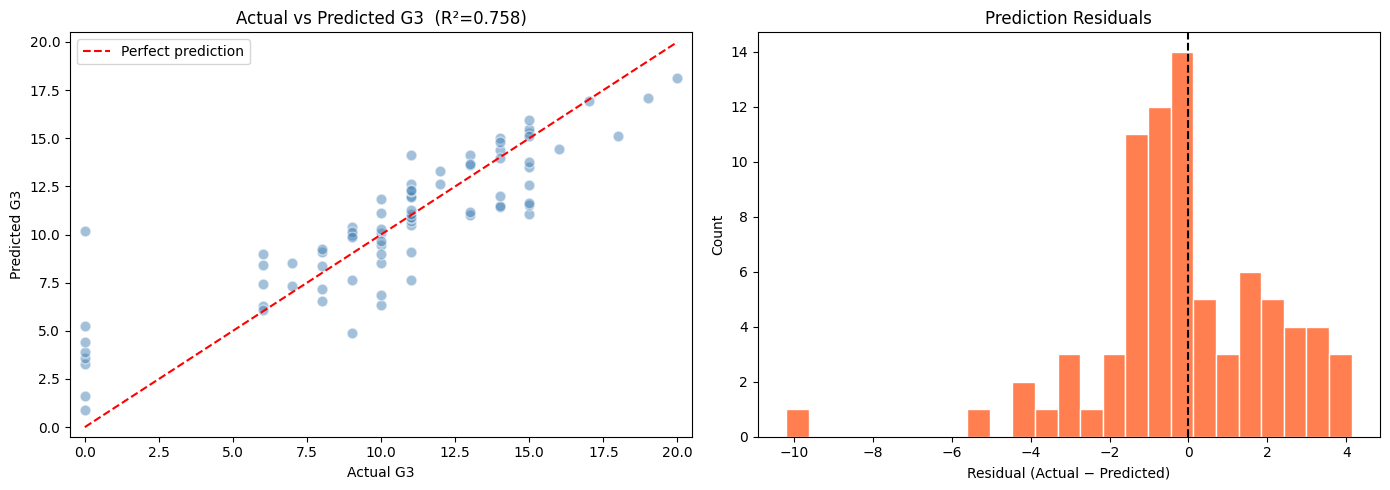

In [56]:
from sklearn.metrics import mean_squared_error,root_mean_squared_error
y_pred_reg = best_xgb_reg.predict(X_test)
# Clip to valid grade range
y_pred_reg = np.clip(y_pred_reg, 0, 20)

mae  = mean_absolute_error(yreg_test, y_pred_reg)
rmse = mean_squared_error(yreg_test, y_pred_reg)
r2   = r2_score(yreg_test, y_pred_reg)

print(f'MAE  : {mae:.3f} grade points')
print(f'RMSE : {rmse:.3f} grade points')
print(f'R²   : {r2:.4f}')
print(f'\n💡 On average, the model predicts G3 within ±{mae:.1f} grade points.')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted scatter
axes[0].scatter(yreg_test, y_pred_reg, alpha=0.5,
                color='steelblue', edgecolors='white', s=60)
axes[0].plot([0,20],[0,20],'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual G3')
axes[0].set_ylabel('Predicted G3')
axes[0].set_title(f'Actual vs Predicted G3  (R²={r2:.3f})')
axes[0].legend()
axes[0].set_xlim(-0.5, 20.5)
axes[0].set_ylim(-0.5, 20.5)

# Residuals
residuals = yreg_test.values - y_pred_reg
axes[1].hist(residuals, bins=25, color='coral', edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title('Prediction Residuals')

plt.tight_layout()
plt.show()

In [57]:
# Grade prediction error breakdown by actual G3 bucket
buckets = pd.cut(yreg_test, bins=[0, 9, 13, 20],
                 labels=['Failing (0-9)', 'Average (10-13)', 'Good (14-20)'],
                 include_lowest=True)
error_df = pd.DataFrame({
    'actual': yreg_test.values,
    'predicted': y_pred_reg,
    'abs_error': np.abs(residuals),
    'bucket': buckets.values
})
print(' MAE by Grade Bins')
print(error_df.groupby('bucket')['abs_error'].agg(['mean','std','count']).round(3))
print('\n💡 Higher error in failing bin is expected — behaviour data is noisier for at-risk students.')

 MAE by Grade Bins
                  mean    std  count
bucket                              
Failing (0-9)    2.198  2.162     26
Average (10-13)  1.207  1.010     31
Good (14-20)     1.605  1.184     22

💡 Higher error in failing bin is expected — behaviour data is noisier for at-risk students.


In [58]:

explainer_clf = shap.TreeExplainer(xgb_clf)
shap_vals_clf = explainer_clf.shap_values(X_test)

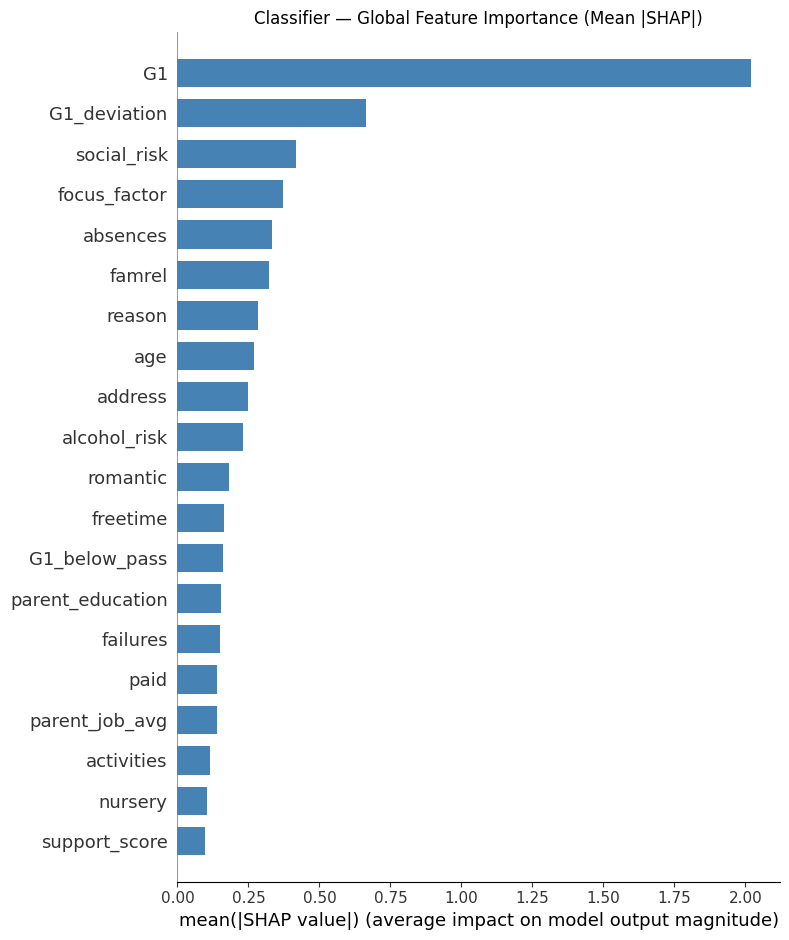

In [59]:
# Global importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_vals_clf, X_test, plot_type='bar',
                  max_display=20, show=False, color='steelblue')
plt.title('Classifier — Global Feature Importance (Mean |SHAP|)')
plt.tight_layout()
plt.show()

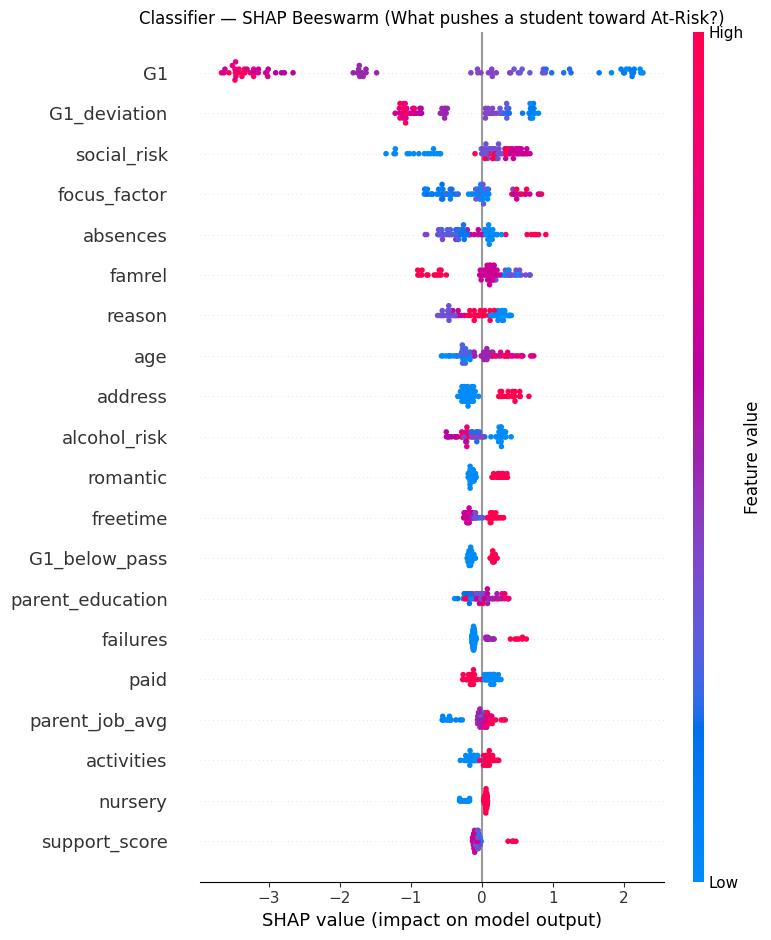

In [60]:
# Beeswarm
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_vals_clf, X_test, max_display=20, show=False)
plt.title('Classifier — SHAP Beeswarm (What pushes a student toward At-Risk?)')
plt.tight_layout()
plt.show()

In [61]:
def generate_interventions(student: pd.Series, shap_clf: np.ndarray,
                           feature_names: list) -> list:
    # Use absolute SHAP values to find the features that moved the needle most
    shap_series = pd.Series(np.abs(shap_clf), index=feature_names)
    top_drivers = shap_series.sort_values(ascending=False).head(6).index.tolist()

    RULES = {
        # --- NEW ENGINEERED FEATURES ---
        'focus_factor':      lambda v: '🎯 Low Focus Factor — high disengagement detected; require mentor check-in' if v < 0.5 else None,
        'effective_time':    lambda v: '🕒 Negative Effective Time — commute is draining study capacity; discuss on-campus stay' if v <= 0 else None,
        'discipline_index':  lambda v: '🛡️ High Discipline Risk — combined social/alcohol impact; refer to student wellness' if v > 8 else None,
        'parent_job_avg':    lambda v: '💼 Limited career exposure — connect with vocational guidance and alumni network' if v <= 1 else None,
        
        # --- REFINED CORE FEATURES ---
        'G1_below_pass':     lambda v: '📚 Failed first assessment — mandatory remedial bridge course enrollment' if v == 1 else None,
        'G1_deviation':      lambda v: '📉 Performing significantly below peers — evaluate for learning resource gaps' if v < -3 else None,
        'failures':          lambda v: f'🔁 {int(v)} prior failure(s) — intensive academic recovery plan required' if v > 0 else None,
        'alcohol_risk':      lambda v: '🍺 Heavy alcohol use detected — priority referral to counseling services' if v >= 6 else None,
        'social_risk':       lambda v: '🌙 High social pressure — workshop on peer pressure and time management' if v >= 6 else None,
        'support_score':     lambda v: '🤝 Critical lack of support — assign a peer buddy and family counselor' if v <= 1 else None,
        'higher':            lambda v: '🎓 No intent for higher studies — session with career motivation coach' if v == 0 else None,
        'health':            lambda v: '🏥 Health concerns — suggest medical leave or reduced course load evaluation' if v <= 2 else None,
    }

    seen, result = set(), []
    for feat in top_drivers:
        if feat in RULES:
            # We use .get() in case a feature was dropped or renamed
            val = student.get(feat, 0)
            iv = RULES[feat](val)
            if iv and iv not in seen:
                result.append(iv)
                seen.add(iv)

    # Return top 4 interventions or a default green message
    return result[:4] if result else ['✅ Student is stable — no immediate intervention required']

In [ ]:
joblib.dump(xgb_clf,       'xgb_classifier_v4.pkl')
joblib.dump(xgb_reg,       'xgb_regressor_v4.pkl')
joblib.dump(explainer_clf, 'shap_explainer_clf_v4.pkl')
joblib.dump(feature_cols,  'feature_cols_v4.pkl')
